In [14]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
import torch
from torch.utils.data import random_split, DataLoader
from model.neumf import NeuMF
from utils.dataset import Observe
import matplotlib.pyplot as plt


In [15]:
embedding_size = 64
batch_size = 1024
data = "coat"
sample_ratio = 4

In [16]:
train = Observe(data, True, sample_ratio=sample_ratio) #! the sample ratio can change
user_num = train.user_num
item_num = train.item_num

train_loader = DataLoader(dataset=train, batch_size=1024, shuffle=True, num_workers=8)


hello


In [17]:
lr = 1e-3
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = NeuMF(user_num, item_num,  embedding_size, embedding_size, [32, 32, 32, 32])
checkpoint = torch.load(f'saved_propensity_model/neumf_propensity_4_{data}.ckpt')
model.load_state_dict(checkpoint['net'])


<All keys matched successfully>

In [18]:
predictions= torch.empty(0)
y_true = torch.empty(0)
model.eval()
for user, item, label in train_loader:
    pred = model(user, item)
    predictions = torch.cat((predictions, pred.cpu()))
    y_true = torch.cat((y_true, label))

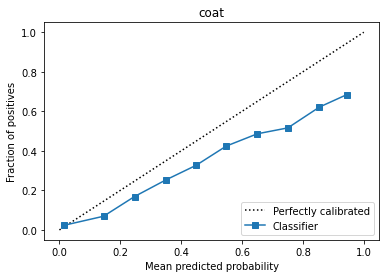

In [19]:
disp = CalibrationDisplay.from_predictions(y_true.detach().numpy(), predictions.detach().numpy(), n_bins=10)
plt.title(data)
# plt.show()
plt.savefig(f"pic/{data}_{sample_ratio}_hist.jpg")